# SVGP α*(x) Double-check (vs true f0)

This notebook:

1. Loads **pointwise_coverage_repXXX_*.csv** files (your calibration outputs).
2. For each replication `rep` and each test point `x_j`, selects **α\*(rep, x_j)** such that estimated coverage is closest to 0.95.
3. For each replication, trains **SVGP two-stage** on **split2** (Stage-1 β=1; Stage-2 covariance-only β=1/α), only for the **distinct α\*** values needed.
4. Builds pointwise CIs and checks coverage against the **true f0(x)** (NOT pseudo-truth).
5. Averages hits over replications to produce a **calibrated pointwise coverage curve** and a plot.

> Assumption: your `alpha_grid.py` calibration used the same data-generation + normalization design (fixed pool by `seed`, per-rep split by `seed+rep_id`).


In [9]:
# --- user settings ---
import os, glob

RESULTS_DIR = r"C:\Users\yangy\26 spring\with reference\results"   # <-- change if needed
TARGET_COVERAGE = 0.95
REPS = list(range(100))  # rep000..rep099
CI_LEVEL = 0.95

# α grid must match calibration outputs' column names
ALPHAS = [1.0, 0.8, 0.6, 0.5, 0.3, 0.1, 0.001]

# speed knobs (CPU notebook)
USE_FP64 = True
USE_CIQ = False     # keep False on CPU unless you know you need CIQ


In [10]:
import numpy as np
import pandas as pd

def rep_csv_path(rep_id:int)->str:
    patt = os.path.join(RESULTS_DIR, f"pointwise_coverage_rep{rep_id:03d}_*.csv")
    hits = glob.glob(patt)
    if not hits:
        raise FileNotFoundError(f"No CSV found for rep {rep_id:03d}: {patt}")
    hits.sort(key=lambda p: os.path.getmtime(p), reverse=True)
    return hits[0]

def load_rep_coverage(rep_id:int)->pd.DataFrame:
    return pd.read_csv(rep_csv_path(rep_id))

# quick sanity check
df0 = load_rep_coverage(99)
display(df0.head())
print(df0.columns.tolist())


,x,alpha_1.0000,alpha_0.8000,alpha_0.6000,alpha_0.5000,alpha_0.3000,alpha_0.1000,alpha_0.0010
0,-2.500000,0.644,0.838,0.982,0.996,1.0,1.0,1.0
1,-2.397959,1.000,1.000,1.000,1.000,1.0,1.0,1.0
2,-2.295918,0.096,0.258,0.650,0.888,1.0,1.0,1.0
3,-2.193878,0.060,0.192,0.558,0.822,1.0,1.0,1.0
4,-2.091837,1.000,1.000,1.000,1.000,1.0,1.0,1.0


['x', 'alpha_1.0000', 'alpha_0.8000', 'alpha_0.6000', 'alpha_0.5000', 'alpha_0.3000', 'alpha_0.1000', 'alpha_0.0010']


## 1) Choose α*(rep, x) from CSVs

Rule used:
- For each `x_j`, pick α that minimizes `|coverage(α,x_j) - TARGET|`.
- If ties, pick the **larger α** (less inflation) among tied candidates.


In [11]:
def alpha_cols_from_df(df: pd.DataFrame):
    cols = [c for c in df.columns if c.startswith("alpha_")]
    def parse_alpha(c):
        return float(c.split("_",1)[1])
    pairs = [(parse_alpha(c), c) for c in cols]
    pairs.sort(key=lambda t: -t[0])  # high to low
    return pairs

def pick_alpha_star_row(row: pd.Series, alpha_pairs, target=0.95):
    best_alpha, best_cov, best_abs = None, None, float("inf")
    for a, col in alpha_pairs:
        cov = float(row[col])
        d = abs(cov - target)
        if d < best_abs - 1e-12:
            best_abs = d
            best_alpha, best_cov = a, cov
        elif abs(d - best_abs) <= 1e-12:
            if a > best_alpha:  # tie-break: larger alpha
                best_alpha, best_cov = a, cov
    return best_alpha, best_cov

alpha_star_by_rep = {}
x_grid = None

for rep in REPS:
    df = load_rep_coverage(rep)
    if x_grid is None:
        x_grid = df["x"].to_numpy()
    else:
        if not np.allclose(x_grid, df["x"].to_numpy()):
            raise ValueError(f"x grid mismatch at rep {rep}")

    alpha_pairs = alpha_cols_from_df(df)
    a_star, a_star_cov = [], []
    for _, row in df.iterrows():
        a, cov = pick_alpha_star_row(row, alpha_pairs, target=TARGET_COVERAGE)
        a_star.append(a)
        a_star_cov.append(cov)

    alpha_star_by_rep[rep] = (np.array(a_star, dtype=float), np.array(a_star_cov, dtype=float))

distinct_counts = [len(np.unique(alpha_star_by_rep[r][0])) for r in REPS]
print(pd.Series(distinct_counts).describe())


count    100.000000
mean       2.410000
std        1.706168
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max        6.000000
dtype: float64


In [12]:
# which alpha* values are chosen (across all reps/points)
all_astars = np.concatenate([alpha_star_by_rep[r][0] for r in REPS])
display(pd.Series(all_astars).value_counts().sort_index(ascending=False))


1.000    4718
0.800      83
0.600      77
0.500      37
0.300      57
0.100      27
0.001       1
Name: count, dtype: int64

## 2) Re-run SVGP two-stage only for distinct α* per rep, and evaluate coverage vs true f0


In [13]:
import math, time
import torch
import gpytorch
from contextlib import ExitStack
from torch.utils.data import DataLoader, TensorDataset

# ---------- helpers copied from calibration design ----------
def f0_torch(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(2 * math.pi * x) + 0.5 * torch.cos(3 * x)

def make_stratified_points_1d(n, low, high, generator, device, dtype):
    i = torch.arange(n, device=device, dtype=dtype)
    u = (i + torch.rand(n, generator=generator, device=device, dtype=dtype)) / n
    x = low + (high - low) * u
    perm = torch.randperm(n, generator=generator, device=device)
    return x[perm].unsqueeze(-1)

def clone_state_dict(sd):
    out = {}
    for k, v in sd.items():
        out[k] = v.detach().clone() if torch.is_tensor(v) else v
    return out

def z_from_ci_level(ci_level: float, device: torch.device, dtype: torch.dtype) -> torch.Tensor:
    p = 0.5 * (1.0 + float(ci_level))
    t = torch.tensor(2.0 * p - 1.0, device=device, dtype=dtype)
    return math.sqrt(2.0) * torch.erfinv(t)

def has_setting(name: str) -> bool:
    return hasattr(gpytorch.settings, name)

def ciq_context(use_ciq: bool):
    if not use_ciq:
        return ExitStack()
    stack = ExitStack()
    for name, val in [
        ("num_contour_quadrature", 15),
        ("ciq_samples", 16),
        ("ciq_max_iter", 30),
        ("ciq_forward_precision", 0.01),
        ("eval_cg_tolerance", 1e-4),
        ("max_root_decomposition_size", 64),
    ]:
        if has_setting(name):
            stack.enter_context(getattr(gpytorch.settings, name)(val))
    stack.enter_context(gpytorch.settings.fast_pred_var(True))
    return stack

# ---------- SVGP model ----------
class SVGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points_std: torch.Tensor):
        M = inducing_points_std.size(0)
        q_dist = gpytorch.variational.CholeskyVariationalDistribution(M)
        q_strat = gpytorch.variational.VariationalStrategy(
            self, inducing_points_std, q_dist, learn_inducing_locations=False
        )
        super().__init__(q_strat)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x_std):
        mean_x = self.mean_module(x_std)
        covar_x = self.covar_module(x_std)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def freeze_all_params(model, likelihood):
    for p in model.parameters():
        p.requires_grad_(False)
    for p in likelihood.parameters():
        p.requires_grad_(False)

def pick_covariance_params_svgp(model):
    trainables = []
    vdist_mod = None
    vs = getattr(model, "variational_strategy", None)
    if vs is not None:
        if hasattr(vs, "_variational_distribution"):
            vdist_mod = getattr(vs, "_variational_distribution")
        else:
            cand = getattr(vs, "variational_distribution", None)
            if isinstance(cand, torch.nn.Module):
                vdist_mod = cand
    if isinstance(vdist_mod, torch.nn.Module):
        for n, p in vdist_mod.named_parameters(recurse=True):
            low = n.lower()
            if "mean" in low:
                p.requires_grad_(False)
            elif any(k in low for k in ["chol", "std", "var", "covar", "factor"]):
                p.requires_grad_(True)
                trainables.append(p)
            else:
                p.requires_grad_(False)
    if not trainables:
        allow = (
            "chol_variational_covar", "variational_distribution.chol_covar",
            "variational_distribution._cholesky_factor", "_variational_distribution.chol_covar",
            "raw_covar", "chol_factor", "covar_factor", "variational_stddev", "raw_var",
            "qchol", "q_scale_tril"
        )
        for n, p in model.named_parameters():
            low = n.lower()
            if "variational_strategy" in low and any(k in low for k in allow) and "mean" not in low:
                p.requires_grad_(True)
                trainables.append(p)
    if not trainables:
        raise RuntimeError("No covariance params found for Stage-2.")
    return trainables

def stage1_train(model, likelihood, x_train_std, y_train_std,
                 lr, epochs, jitter, batch_size,
                 early_stop_patience=60, early_stop_min_delta=1e-4,
                 use_ciq=False):
    N = x_train_std.size(0)
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=1.0)
    likelihood.noise_covar.raw_noise.requires_grad_(False)

    opt = torch.optim.Adam([
        {"params": model.variational_parameters()},
        {"params": model.hyperparameters()},
        {"params": likelihood.parameters()},
    ], lr=lr)

    loader = DataLoader(TensorDataset(x_train_std, y_train_std),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    model.train(); likelihood.train()
    best_loss, best_epoch = float("inf"), 0
    best_m, best_l = clone_state_dict(model.state_dict()), clone_state_dict(likelihood.state_dict())
    patience = 0

    with ciq_context(use_ciq):
        with gpytorch.settings.cholesky_jitter(jitter):
            for ep in range(1, epochs + 1):
                total, nb = 0.0, 0
                for xb, yb in loader:
                    opt.zero_grad(set_to_none=True)
                    out = model(xb)
                    loss = -mll(out, yb)
                    if loss.numel() > 1:
                        loss = loss.mean()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                    opt.step()
                    total += float(loss.item()); nb += 1
                avg = total / max(1, nb)

                if best_loss - avg > early_stop_min_delta:
                    best_loss, best_epoch = avg, ep
                    best_m, best_l = clone_state_dict(model.state_dict()), clone_state_dict(likelihood.state_dict())
                    patience = 0
                else:
                    patience += 1
                if patience >= early_stop_patience:
                    break

    model.load_state_dict(best_m); likelihood.load_state_dict(best_l)
    model.eval(); likelihood.eval()
    return best_epoch, best_loss

def stage2_cov_only(model, likelihood, x_train_std, y_train_std,
                    beta, lr, epochs, jitter, batch_size,
                    use_ciq=False):
    N = x_train_std.size(0)
    freeze_all_params(model, likelihood)
    cov_params = pick_covariance_params_svgp(model)
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=beta)
    opt = torch.optim.Adam(cov_params, lr=lr)
    loader = DataLoader(TensorDataset(x_train_std, y_train_std),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    model.train(); likelihood.train()
    best_loss = float("inf")
    best_m, best_l = clone_state_dict(model.state_dict()), clone_state_dict(likelihood.state_dict())

    with ciq_context(use_ciq):
        with gpytorch.settings.cholesky_jitter(jitter):
            for _ in range(1, epochs + 1):
                total, nb = 0.0, 0
                for xb, yb in loader:
                    opt.zero_grad(set_to_none=True)
                    out = model(xb)
                    loss = -mll(out, yb)
                    if loss.numel() > 1:
                        loss = loss.mean()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(cov_params, 5.0)
                    opt.step()
                    total += float(loss.item()); nb += 1
                avg = total / max(1, nb)
                if avg < best_loss:
                    best_loss = avg
                    best_m, best_l = clone_state_dict(model.state_dict()), clone_state_dict(likelihood.state_dict())

    model.load_state_dict(best_m); likelihood.load_state_dict(best_l)
    model.eval(); likelihood.eval()
    return best_loss


In [14]:
# --- experiment config (match calibration) ---
class CFG:
    n_train = 500
    n_test = 50
    train_low = -2.5
    train_high =  2.5
    test_low = -2.5
    test_high =  2.5

    inducing_points = 50
    seed = 13

    stage1_epochs = 2000
    stage2_epochs = 800
    batch_size = 500
    lr_adam_stage1 = 2e-2
    lr_adam_stage2 = 2e-2
    jitter = 1e-2
    noise_raw = 3e-3

    early_stop_patience = 60
    early_stop_min_delta = 1e-4

cfg = CFG()

device = torch.device("cpu")
torch.set_default_dtype(torch.float64 if USE_FP64 else torch.float32)
dtype = torch.get_default_dtype()

# fixed pool
pool_gen = torch.Generator(device=device).manual_seed(int(cfg.seed))
x_train_raw = make_stratified_points_1d(cfg.n_train, cfg.train_low, cfg.train_high, pool_gen, device, dtype)
x_test_raw = torch.linspace(cfg.test_low, cfg.test_high, cfg.n_test, device=device, dtype=dtype).unsqueeze(1)

y_train_raw = f0_torch(x_train_raw).squeeze(-1)
y_test_true_raw = f0_torch(x_test_raw).squeeze(-1)

# x normalization
train_low_t = torch.as_tensor(cfg.train_low, device=device, dtype=dtype)
train_high_t = torch.as_tensor(cfg.train_high, device=device, dtype=dtype)
span = (train_high_t - train_low_t).clamp_min(1e-12)
def x_to_std(x_raw):
    x01 = (x_raw - train_low_t) / span
    return 2.0 * x01 - 1.0

x_train_std_full = x_to_std(x_train_raw)
x_test_std = x_to_std(x_test_raw)
Z_raw = torch.linspace(cfg.train_low, cfg.train_high, cfg.inducing_points, device=device, dtype=dtype).unsqueeze(1)
Z_std = x_to_std(Z_raw)

# y standardization on full pool
y_mean = y_train_raw.mean()
y_scale = y_train_raw.std(unbiased=False).clamp_min(1e-12)
y_train_std_full = (y_train_raw - y_mean) / y_scale
noise_std = torch.as_tensor(cfg.noise_raw, device=device, dtype=dtype) / (y_scale ** 2)

z_ci = float(z_from_ci_level(CI_LEVEL, device=device, dtype=dtype).item())
print("z_ci =", z_ci)


z_ci = 1.959963984540054


In [15]:
from collections import defaultdict

def build_split_indices(rep_id:int, n:int, seed:int):
    g = torch.Generator(device=device).manual_seed(int(seed + rep_id))
    perm = torch.randperm(n, generator=g, device=device)
    half = n // 2
    return perm[:half], perm[half:]

def train_split2_base_and_alpha_hits(rep_id:int, distinct_alphas):
    s1_idx, s2_idx = build_split_indices(rep_id, cfg.n_train, cfg.seed)
    x_s2 = x_train_std_full[s2_idx]
    y_s2 = y_train_std_full[s2_idx]

    model = SVGPModel(Z_std.clone().contiguous()).to(device=device)
    lik = gpytorch.likelihoods.GaussianLikelihood().to(device=device)
    with torch.no_grad():
        model.covar_module.base_kernel.lengthscale.fill_(1.0)
        model.covar_module.outputscale.fill_(1.0)
        lik.noise = noise_std
    lik.noise_covar.raw_noise.requires_grad_(False)

    stage1_train(
        model, lik, x_s2, y_s2,
        lr=cfg.lr_adam_stage1,
        epochs=cfg.stage1_epochs,
        jitter=cfg.jitter,
        batch_size=cfg.batch_size,
        early_stop_patience=cfg.early_stop_patience,
        early_stop_min_delta=cfg.early_stop_min_delta,
        use_ciq=USE_CIQ,
    )

    base_m = clone_state_dict(model.state_dict())
    base_l = clone_state_dict(lik.state_dict())

    hits_by_alpha = {}
    for alpha in sorted([float(a) for a in distinct_alphas], reverse=True):
        beta = 1.0 / alpha

        model.load_state_dict(base_m)
        lik.load_state_dict(base_l)
        model.eval(); lik.eval()

        stage2_cov_only(
            model, lik, x_s2, y_s2,
            beta=beta,
            lr=cfg.lr_adam_stage2,
            epochs=cfg.stage2_epochs,
            jitter=cfg.jitter,
            batch_size=cfg.batch_size,
            use_ciq=USE_CIQ,
        )

        with torch.no_grad():
            pred = model(x_test_std)
            mu_std = pred.mean
            var_std = pred.variance.clamp_min(1e-24)

            mu_raw = mu_std * y_scale + y_mean
            std_raw = (var_std * (y_scale ** 2)).sqrt().clamp_min(1e-12)

            lo = mu_raw - z_ci * std_raw
            hi = mu_raw + z_ci * std_raw

            hits = ((y_test_true_raw >= lo) & (y_test_true_raw <= hi)).to(torch.int8).cpu().numpy()

        hits_by_alpha[alpha] = hits
    return hits_by_alpha

# Main double-check
R = len(REPS)
J = len(x_grid)
hits_matrix = np.zeros((R, J), dtype=np.int8)

t0 = time.time()
for rr, rep in enumerate(REPS):
    a_star = alpha_star_by_rep[rep][0]  # [J]
    distinct = np.unique(a_star)

    hits_by_alpha = train_split2_base_and_alpha_hits(rep, distinct)

    out_hits = np.zeros(J, dtype=np.int8)
    for j in range(J):
        out_hits[j] = hits_by_alpha[float(a_star[j])][j]
    hits_matrix[rr, :] = out_hits

    if (rr+1) % max(1, R//10) == 0:
        print(f"rep {rep:03d} done ({rr+1}/{R}) | distinct alphas={len(distinct)} | elapsed={(time.time()-t0)/60:.1f} min")

doublecheck_coverage = hits_matrix.mean(axis=0)
print("mean coverage over x =", doublecheck_coverage.mean())


rep 009 done (10/100) | distinct alphas=5 | elapsed=3.2 min
rep 019 done (20/100) | distinct alphas=2 | elapsed=6.1 min
rep 029 done (30/100) | distinct alphas=4 | elapsed=9.3 min
rep 039 done (40/100) | distinct alphas=1 | elapsed=12.0 min
rep 049 done (50/100) | distinct alphas=4 | elapsed=15.3 min
rep 059 done (60/100) | distinct alphas=2 | elapsed=18.8 min
rep 069 done (70/100) | distinct alphas=1 | elapsed=22.1 min
rep 079 done (80/100) | distinct alphas=1 | elapsed=24.9 min
rep 089 done (90/100) | distinct alphas=4 | elapsed=28.6 min
rep 099 done (100/100) | distinct alphas=3 | elapsed=31.6 min
mean coverage over x = 0.9752


Saved: C:\Users\yangy\26 spring\with reference\results\doublecheck_pointwise_coverage_vs_f0.csv


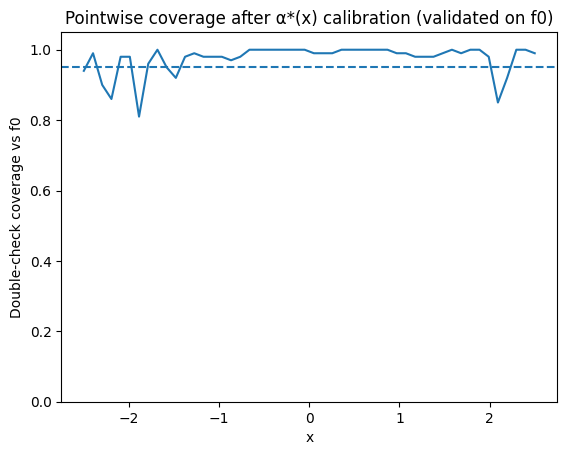

In [16]:
# Save results + plot
import matplotlib.pyplot as plt

out_csv = os.path.join(RESULTS_DIR, "doublecheck_pointwise_coverage_vs_f0.csv")
pd.DataFrame({"x": x_grid, "coverage": doublecheck_coverage}).to_csv(out_csv, index=False)
print("Saved:", out_csv)

plt.figure()
plt.plot(x_grid, doublecheck_coverage)
plt.axhline(TARGET_COVERAGE, linestyle="--")
plt.ylim(0.0, 1.05)
plt.xlabel("x")
plt.ylabel("Double-check coverage vs f0")
plt.title("Pointwise coverage after α*(x) calibration (validated on f0)")
plt.show()


### Notes
- If the calibration CSV already has coverage ≈ 1 for all α at most x, α\* selection becomes dominated by the tie-break rule.
- For a quick sanity check, set `REPS = list(range(5))` first.
